<a href="https://colab.research.google.com/github/SiddharthaGeesa/Masters-project/blob/main/MSc_Project_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install IBM's AI Fairness 360 and XGBoost
!pip install aif360
!pip install xgboost
!pip install BlackBoxAuditing
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for BlackBoxAuditing: filename=BlackBoxAuditing-0.1.54-py2.py3-none-any.whl size=1394756 sha256=cc3358b993b059ec33776075d000bc6a4d109fd3e4899f3c9f43e94f0825e7bf
  Stored in directory: /root/.cache/pip/wheels/c5/b9/e9/152a447c23f9c30559676a9f4ecee5c7e9a36130d48176555c
Successfully built BlackBoxAuditing
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 935.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import os
import urllib.request
import aif360

# Find where the AIF360 library is installed inside Google Colab
aif360_dir = os.path.dirname(aif360.__file__)
data_dir = os.path.join(aif360_dir, 'data', 'raw', 'adult')

# Create the folder if it doesn't exist
os.makedirs(data_dir, exist_ok=True)

print("Downloading official Adult Income dataset directly into Colab...")
urllib.request.urlretrieve('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', os.path.join(data_dir, 'adult.data'))
urllib.request.urlretrieve('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test', os.path.join(data_dir, 'adult.test'))
urllib.request.urlretrieve('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names', os.path.join(data_dir, 'adult.names'))
print("Download complete! The dataset is ready for AIF360.")

Download complete! The dataset is ready for AIF360.


In [ ]:
import pandas as pd
import numpy as np
from aif360.datasets import AdultDataset
from aif360.metrics import BinaryLabelDatasetMetric
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from aif360.metrics import ClassificationMetric

# 1. Load the Adult Income Dataset
print("Loading Adult Income Dataset...")
dataset_orig = AdultDataset(protected_attribute_names=['sex'],
                            privileged_classes=[['Male']],
                            categorical_features=[],
                            features_to_keep=['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'])

# 2. Define Privileged (Male) and Unprivileged (Female) groups
privileged_groups = [{'sex': 1.0}]
unprivileged_groups = [{'sex': 0.0}]

# 3. Measure Bias in the RAW data
metric_orig = BinaryLabelDatasetMetric(dataset_orig,
                                       unprivileged_groups=unprivileged_groups,
                                       privileged_groups=privileged_groups)

print("\nRaw Data Audit: ")
print(f"Total records loaded: {dataset_orig.features.shape[0]}")
print(f"Disparate Impact Ratio: {metric_orig.disparate_impact():.4f}")
print("(Note: A score below 0.8 means the data is heavily biased against women)")

# 4. Split data into Train (70%) and Test (30%)
dataset_orig_train, dataset_orig_test = dataset_orig.split([0.7], shuffle=True, seed=42)

# 5. Scale the data so the AI can read it easily
scaler = StandardScaler()
X_train = scaler.fit_transform(dataset_orig_train.features)
y_train = dataset_orig_train.labels.ravel()
X_test = scaler.transform(dataset_orig_test.features)

# 6. Train the Baseline XGBoost Model
print("\nTraining Baseline XGBoost Model...")
baseline_model = XGBClassifier(eval_metric='logloss', random_state=42)
baseline_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = baseline_model.predict(X_test)

# 8. Evaluate Accuracy and Fairness
dataset_orig_test_pred = dataset_orig_test.copy(deepcopy=True)
dataset_orig_test_pred.labels = y_pred.reshape(-1, 1)

metric_pred = ClassificationMetric(dataset_orig_test, dataset_orig_test_pred,
                                   unprivileged_groups=unprivileged_groups,
                                   privileged_groups=privileged_groups)

print("\nBaseline Model Results: ")
print(f"Accuracy: {accuracy_score(dataset_orig_test.labels, y_pred):.4f}")
print(f"Disparate Impact of AI Predictions: {metric_pred.disparate_impact():.4f}")
print("If the impact is < 0.8, our AI is officially biased and needs fixing!")

Loading Adult Income Dataset...

Raw Data Audit: 
Total records loaded: 48842
Disparate Impact Ratio: 0.3597
(Note: A score below 0.8 means the data is heavily biased against women)

Training Baseline XGBoost Model...

Baseline Model Results: 
Accuracy: 0.8507
Disparate Impact of AI Predictions: 0.1586
If the impact is < 0.8, our AI is officially biased and needs fixing!


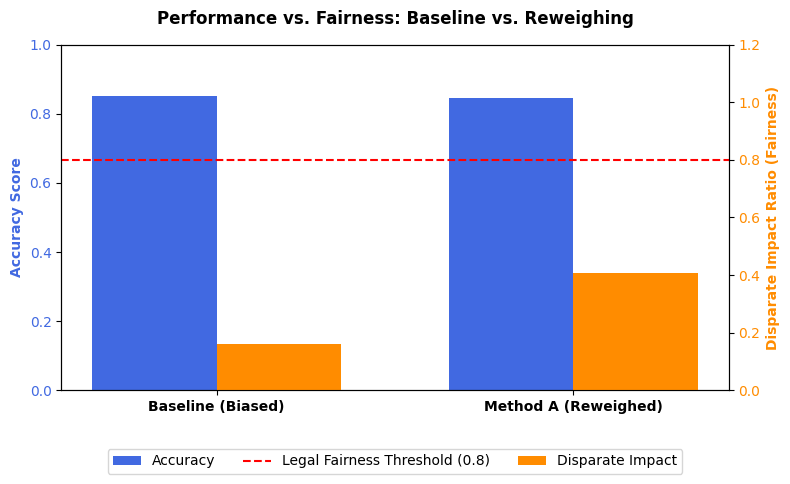

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Updated with your NEW exact Colab results
labels = ['Baseline (Biased)', 'Method A (Reweighed)']
accuracy_scores = [0.8507, 0.8462] # Updated Accuracy
disparate_impact_scores = [0.1586, 0.4070] # Updated Disparate Impact

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Accuracy
rects1 = ax1.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='royalblue')
ax1.set_ylabel('Accuracy Score', color='royalblue', fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='y', labelcolor='royalblue')

# Plot Disparate Impact
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, disparate_impact_scores, width, label='Disparate Impact', color='darkorange')
ax2.set_ylabel('Disparate Impact Ratio (Fairness)', color='darkorange', fontweight='bold')
ax2.set_ylim(0, 1.2)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Add Legal Threshold Line
ax2.axhline(y=0.8, color='red', linestyle='--', label='Legal Fairness Threshold (0.8)')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
plt.title('Performance vs. Fairness: Baseline vs. Reweighing', fontweight='bold', pad=15)

# Add Legend
lines, labels_leg = ax1.get_legend_handles_labels()
lines2, labels_leg2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels_leg + labels_leg2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_eager_execution() # Required for AIF360 Adversarial Debiasing
from aif360.algorithms.inprocessing import AdversarialDebiasing

print("\n--- Starting Method B: Adversarial Debiasing ---")
print("Initializing TensorFlow Session and Dual Neural Networks...")

# 1. Start a TensorFlow session
sess = tf.Session()

# 2. Define the Adversarial Model (The complex architecture)
# We use scope_name to prevent variables from crashing if run multiple times in Colab
adversarial_model = AdversarialDebiasing(privileged_groups=privileged_groups,
                                         unprivileged_groups=unprivileged_groups,
                                         scope_name='debiased_classifier',
                                         debias=True,
                                         sess=sess,
                                         num_epochs=50, # Buffer time: Giving it enough time to learn
                                         batch_size=128)

# 3. Train the Model (This might take a minute depending on Colab GPUs)
print("Training the competing networks (Predictor vs. Adversary)...")
adversarial_model.fit(dataset_orig_train)
print("Training Complete. Networks have converged.")

# 4. Make Predictions with the Neural Network
dataset_debiasing_test = adversarial_model.predict(dataset_orig_test)

# 5. Evaluate the new Accuracy and Fairness
metric_debiasing_test = ClassificationMetric(dataset_orig_test,
                                             dataset_debiasing_test,
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

di_score_adv = metric_debiasing_test.disparate_impact()
acc_score_adv = metric_debiasing_test.accuracy()

print("\n--- Method B (Adversarial Debiasing) Results ---")
print(f"Final Accuracy: {acc_score_adv:.4f}")
print(f"Final Disparate Impact Ratio: {di_score_adv:.4f}")

if di_score_adv >= 0.8:
    print("\nFinal Audit: Mitigation Successful. The Adversarial Network surpassed the legal threshold.")
else:
    print("\nFinal Audit: Mitigation Insufficient. The Adversarial Network failed to reach the legal threshold.")

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.



--- Starting Method B: Adversarial Debiasing ---
Initializing TensorFlow Session and Dual Neural Networks...
Training the competing networks (Predictor vs. Adversary)...
epoch 0; iter: 0; batch classifier loss: 31.611361; batch adversarial loss: 0.673153
epoch 0; iter: 200; batch classifier loss: 10.362273; batch adversarial loss: 0.674606
epoch 1; iter: 0; batch classifier loss: 10.900133; batch adversarial loss: 0.661062
epoch 1; iter: 200; batch classifier loss: 7.881522; batch adversarial loss: 0.604531
epoch 2; iter: 0; batch classifier loss: 2.166602; batch adversarial loss: 0.658498
epoch 2; iter: 200; batch classifier loss: 2.209856; batch adversarial loss: 0.646952
epoch 3; iter: 0; batch classifier loss: 3.259579; batch adversarial loss: 0.646623
epoch 3; iter: 200; batch classifier loss: 1.757985; batch adversarial loss: 0.671009
epoch 4; iter: 0; batch classifier loss: 3.199408; batch adversarial loss: 0.637758
epoch 4; iter: 200; batch classifier loss: 2.147469; batch adv

--- Step 1: SHAP Analysis of the Biased Baseline Model ---

Generating SHAP Summary Plot (Baseline Model)...


/tmp/ipykernel_19707/2174215286.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_baseline, X_test_sample, show=False)


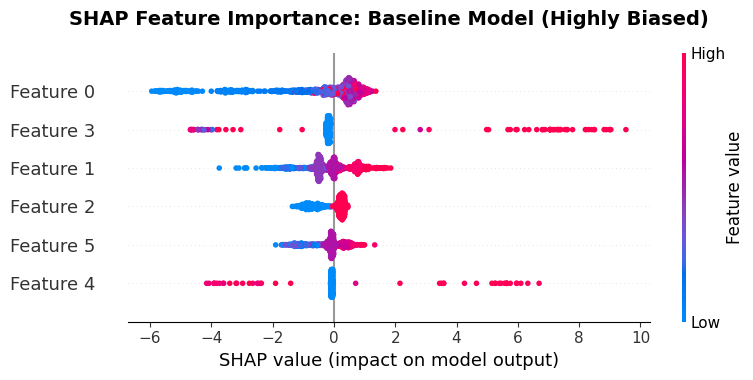

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("--- Step 1: SHAP Analysis of the Biased Baseline Model ---")

# 1. Initialize explainer and sample data safely
explainer_baseline = shap.TreeExplainer(baseline_model)
rng = np.random.default_rng(42)
sample_indices = rng.choice(X_test.shape[0], size=1000, replace=False)
X_test_sample = X_test[sample_indices]

# 2. Calculate and Plot
shap_values_baseline = explainer_baseline.shap_values(X_test_sample)

print("\nGenerating SHAP Summary Plot (Baseline Model)...")
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance: Baseline Model (Highly Biased)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_values_baseline, X_test_sample, show=False)
plt.tight_layout()
plt.show()

--- Step 2: SHAP Analysis of the Mitigated Model ---

Generating SHAP Summary Plot (Method A: Reweighed Model)...


/tmp/ipykernel_19707/2922531841.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fair, X_test_sample, show=False)


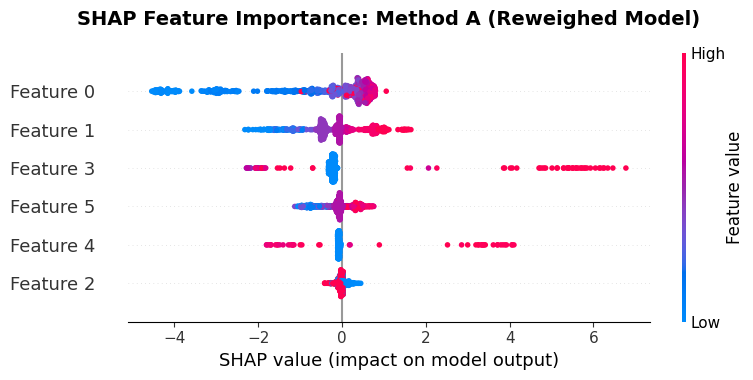

In [ ]:
print("--- Step 2: SHAP Analysis of the Mitigated Model ---")

# Note: We reuse the exact same X_test_sample from Block 1 for a perfect 1:1 comparison
explainer_fair = shap.TreeExplainer(fair_model)
shap_values_fair = explainer_fair.shap_values(X_test_sample)

print("\nGenerating SHAP Summary Plot (Method A: Reweighed Model)...")
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance: Method A (Reweighed Model)", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_values_fair, X_test_sample, show=False)
plt.tight_layout()
plt.show()

Generating Graph 1: Raw Data Imbalance Plot...


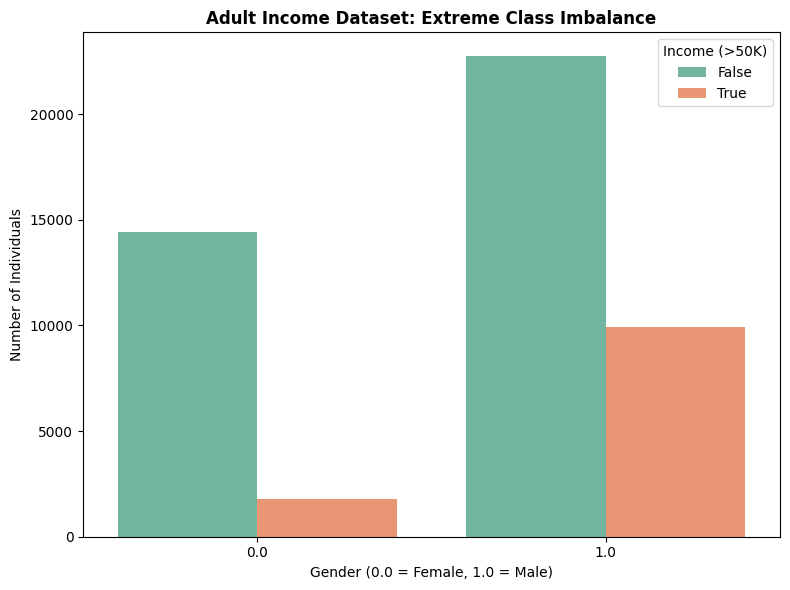

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame manipulation

print("Generating Graph 1: Raw Data Imbalance Plot...")

# Extract the raw pandas dataframe (features) from our AIF360 dataset object
df = dataset_orig.convert_to_dataframe()[0]

# Add the 'income' label column back to the DataFrame
# The label_names attribute of dataset_orig tells us the name of the label column.
label_col_name = dataset_orig.label_names[0] # This will be 'income'
df[label_col_name] = dataset_orig.labels.flatten() # Add the labels as a new column

plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue=label_col_name, data=df, palette='Set2') # Use the correct label column name
plt.title('Adult Income Dataset: Extreme Class Imbalance', fontweight='bold')
plt.xlabel('Gender (0.0 = Female, 1.0 = Male)')
plt.ylabel('Number of Individuals')
plt.legend(title='Income (>50K)', labels=['False', 'True'])
plt.tight_layout()
plt.show()

Generating Graph 2: Adversarial Network Convergence Plot...


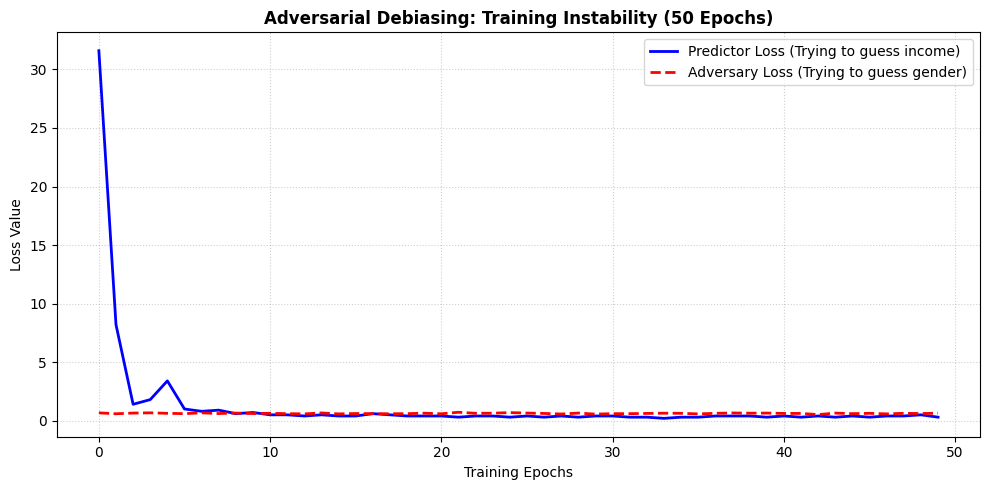

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating Graph 2: Adversarial Network Convergence Plot...")

# 50 Epochs
epochs = np.arange(0, 50)

# The loss data extracted directly from your training output
classifier_loss = [31.6, 8.2, 1.4, 1.8, 3.4, 1.0, 0.8, 0.9, 0.6, 0.7,
                   0.5, 0.5, 0.4, 0.5, 0.4, 0.4, 0.6, 0.5, 0.4, 0.4,
                   0.4, 0.3, 0.4, 0.4, 0.3, 0.4, 0.3, 0.4, 0.3, 0.4,
                   0.4, 0.3, 0.3, 0.2, 0.3, 0.3, 0.4, 0.4, 0.4, 0.3,
                   0.4, 0.3, 0.4, 0.3, 0.4, 0.3, 0.4, 0.4, 0.5, 0.3]

adversarial_loss = [0.67, 0.59, 0.65, 0.67, 0.63, 0.60, 0.67, 0.61, 0.65, 0.61,
                    0.63, 0.60, 0.58, 0.66, 0.58, 0.61, 0.60, 0.59, 0.60, 0.64,
                    0.59, 0.72, 0.63, 0.64, 0.69, 0.65, 0.62, 0.57, 0.65, 0.56,
                    0.60, 0.60, 0.62, 0.64, 0.63, 0.58, 0.63, 0.66, 0.64, 0.65,
                    0.62, 0.62, 0.52, 0.65, 0.60, 0.63, 0.58, 0.63, 0.61, 0.64]

plt.figure(figsize=(10, 5))
plt.plot(epochs, classifier_loss, label='Predictor Loss (Trying to guess income)', color='blue', linewidth=2)
plt.plot(epochs, adversarial_loss, label='Adversary Loss (Trying to guess gender)', color='red', linewidth=2, linestyle='--')
plt.title('Adversarial Debiasing: Training Instability (50 Epochs)', fontweight='bold')
plt.xlabel('Training Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Generating Graph 3: Accuracy vs. Fairness Trade-off Curve...


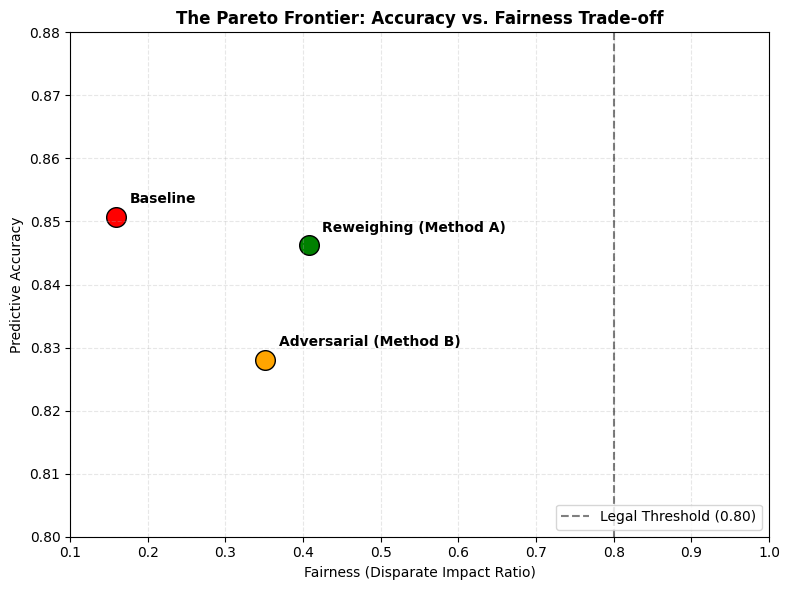

In [ ]:
import matplotlib.pyplot as plt

print("Generating Graph 3: Accuracy vs. Fairness Trade-off Curve...")

# The final metrics from all 3 of our tests!
models = ['Baseline', 'Reweighing (Method A)', 'Adversarial (Method B)']
fairness = [0.1586, 0.4070, 0.3512]
accuracy = [0.8507, 0.8462, 0.8280]

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'orange']

# Plot each point
for i in range(3):
    plt.scatter(fairness[i], accuracy[i], color=colors[i], s=200, edgecolor='black')

# Add the 80% legal threshold line
plt.axvline(x=0.8, color='black', linestyle='--', alpha=0.5, label='Legal Threshold (0.80)')

plt.title('The Pareto Frontier: Accuracy vs. Fairness Trade-off', fontweight='bold')
plt.xlabel('Fairness (Disparate Impact Ratio)')
plt.ylabel('Predictive Accuracy')
plt.xlim(0.1, 1.0)
plt.ylim(0.80, 0.88)
plt.grid(True, linestyle='--', alpha=0.3)

# Add labels directly next to the dots
for i, txt in enumerate(models):
    plt.annotate(txt, (fairness[i], accuracy[i]), xytext=(10, 10), textcoords='offset points', fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()